# LOAN APPROVAL-PREDICTION-SYS  

In [462]:
# importing neccssary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

### Collecting data 

In [463]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [464]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [465]:
df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [466]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

### NO null values presented

In [467]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4264    False
4265    False
4266    False
4267    False
4268    False
Length: 4269, dtype: bool

In [468]:
df.dtypes

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

In [469]:
df = df.drop('loan_id',axis=1)

In [470]:
cat_cols = df.select_dtypes(include=['object','category']).columns
print(cat_cols)

Index([' education', ' self_employed', ' loan_status'], dtype='object')


In [471]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['no_of_dependents', 'education', 'self_employed', 'income_annum',
       'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value',
       'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value',
       'loan_status'],
      dtype='object')


### education , self_employed , loan_status as only 2 unique catagories so Label encoding is best and sutiable
- label-encoding

In [472]:
le = LabelEncoder()

df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])
df['loan_status'] = le.fit_transform(df['loan_status'])

## Successfully converted catagorical values into numerical values 

In [473]:
df.dtypes

no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object

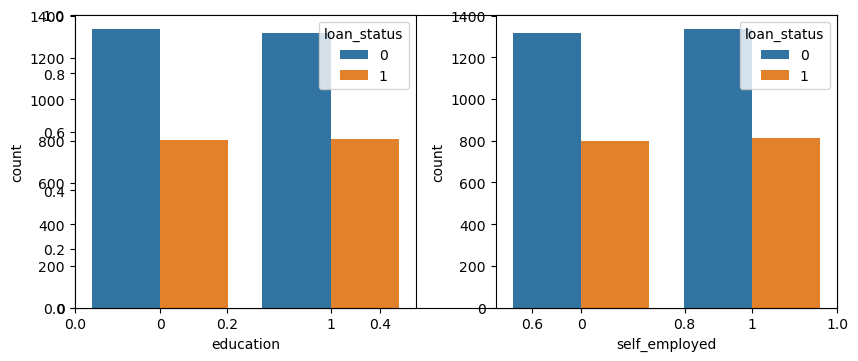

In [474]:
plt.subplots(figsize=(9,4))

for i, col in enumerate(['education','self_employed']):
    plt.subplot(1, 2, i+1)
    sns.countplot(data=df, x=col, hue='loan_status') 
plt.tight_layout()
plt.show()

In [475]:
df.dtypes

no_of_dependents            int64
education                   int64
self_employed               int64
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                 int64
dtype: object

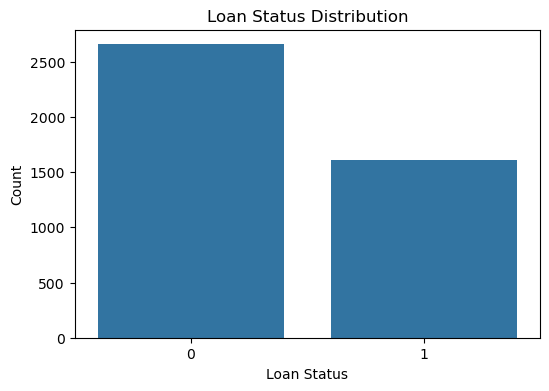

loan_status
0    62.215976
1    37.784024
Name: proportion, dtype: float64


In [476]:
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")

plt.show()
print(df['loan_status'].value_counts(normalize=True)*100)

# feature scaling

In [477]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# Split first
X = df.drop(['loan_status'], axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Select numeric columns
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# Create pipeline (rename variable!)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Train model (NO fit_transform here)
pipe.fit(X_train[num_cols], y_train)

# Predict
y_pred = pipe.predict(X_test[num_cols])

In [478]:
from sklearn.metrics import accuracy_score

train_pred = pipe.predict(X_train)
test_pred = pipe.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.977751756440281


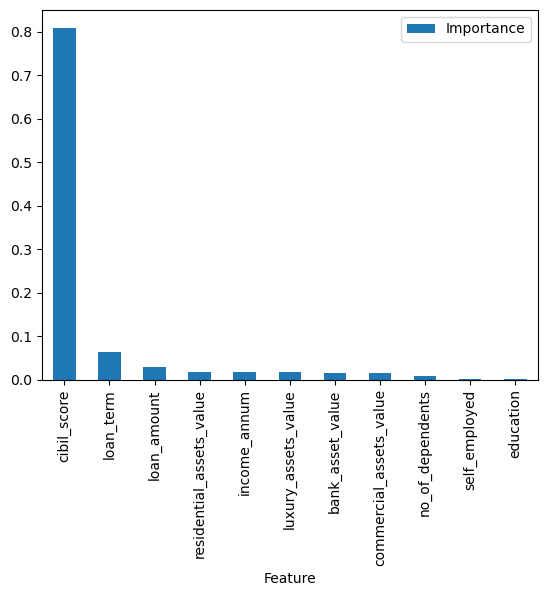

In [479]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_

# Convert to DataFrame for readability
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

#sorting in ascending order 
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

#visualization
feature_importance_df.plot(
    x='Feature', y='Importance', kind='bar'
)
plt.show()

# EDA - Explorative Data Analysis
- checking distribution of data
- Detecting outliers 
- finding realtionships 

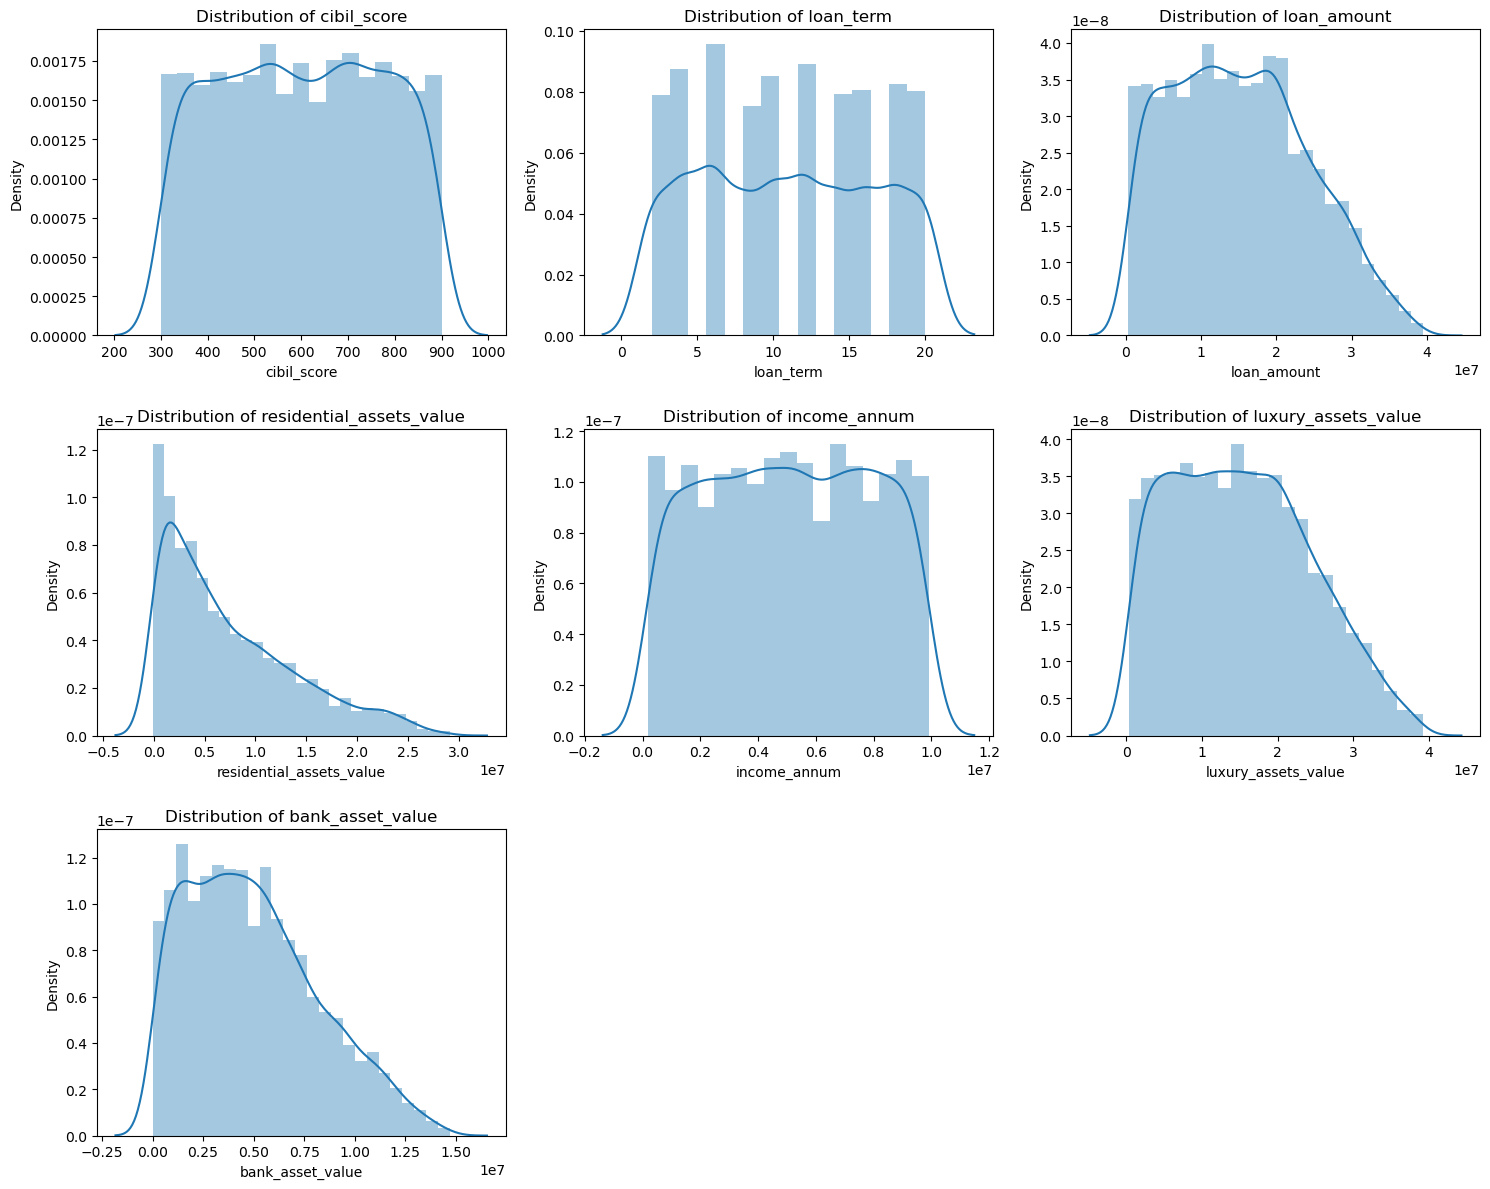

Skewness of features:
residential_assets_value    0.978451
bank_asset_value            0.560725
luxury_assets_value         0.322208
loan_amount                 0.308724
loan_term                   0.036359
cibil_score                -0.009039
income_annum               -0.012814
dtype: float64


In [480]:
# Select numeric columns
selected_cols = ['cibil_score','loan_term','loan_amount','residential_assets_value','income_annum','luxury_assets_value','bank_asset_value']
# Plot distributions
n_features = len(selected_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    sns.distplot(df[col],bins = 'auto', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Remove empty plots
for j in range(len(selected_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Print skewness
print("Skewness of features:")
print(df[selected_cols].skew().sort_values(ascending=False))

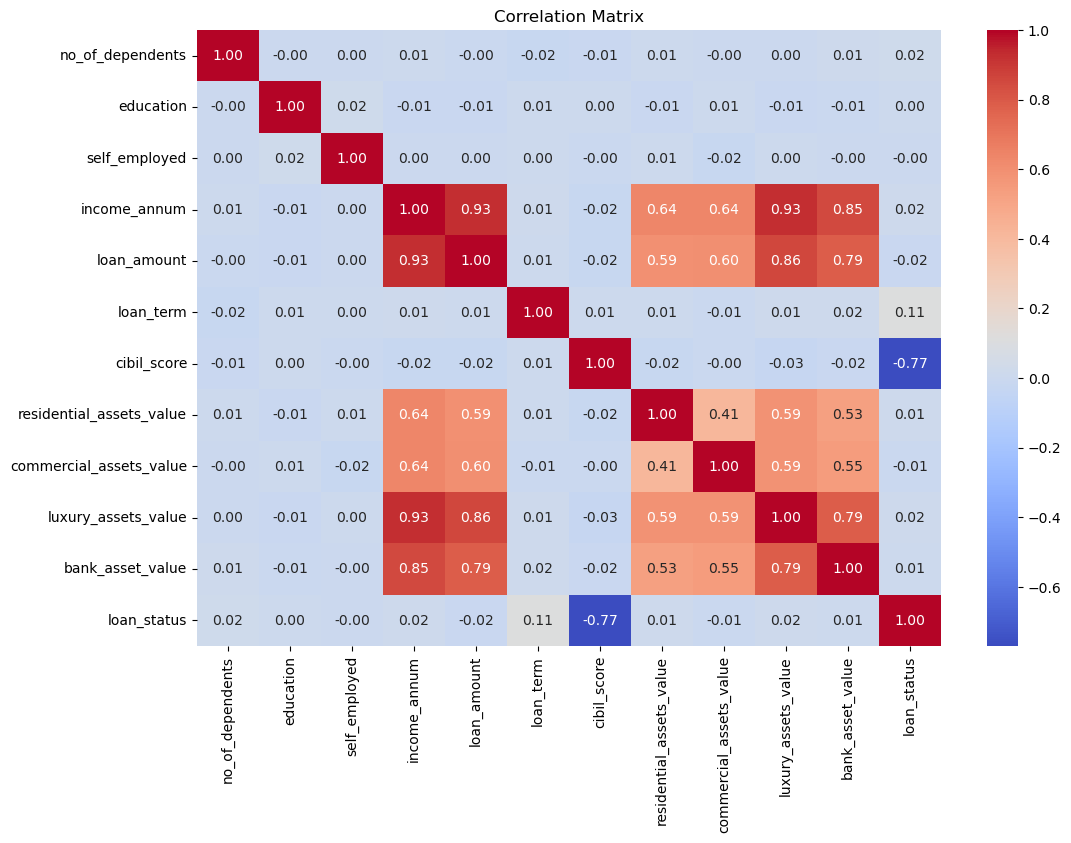

loan_status                 1.000000
loan_term                   0.113036
no_of_dependents            0.018114
luxury_assets_value         0.015465
income_annum                0.015189
residential_assets_value    0.014367
bank_asset_value            0.006778
education                   0.004918
self_employed              -0.000345
commercial_assets_value    -0.008246
loan_amount                -0.016150
cibil_score                -0.770518
Name: loan_status, dtype: float64


In [481]:
num_data = df.select_dtypes(include='number')

corr = num_data.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

if 'loan_status' in corr.columns:
    print(corr['loan_status'].sort_values(ascending=False))

In [482]:
selected_corr_features = corr[abs(corr) > 0.05].index
selected_corr_features = selected_corr_features.drop('loan_status')

In [483]:
num_cols = df.select_dtypes(include='number')

# Display outlier percentage for each column
def detect_outliers(num_cols):
    outliers_info = {}
    for col in num_cols.columns:
        Q1 = num_cols[col].quantile(0.25)
        Q3 = num_cols[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = num_cols[(num_cols[col] < lower_bound) | (num_cols[col] > upper_bound)]
        outlier_percentage = (len(outliers) / len(num_cols)) * 100

        print(f"{col} → Outliers: {len(outliers)} rows ({outlier_percentage:.2f}%)")

        # store info for this column
        outliers_info[col] = {
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'outlier_percentage': outlier_percentage
        }
    return outliers_info

outliers_info = detect_outliers(num_cols)

no_of_dependents → Outliers: 0 rows (0.00%)
education → Outliers: 0 rows (0.00%)
self_employed → Outliers: 0 rows (0.00%)
income_annum → Outliers: 0 rows (0.00%)
loan_amount → Outliers: 0 rows (0.00%)
loan_term → Outliers: 0 rows (0.00%)
cibil_score → Outliers: 0 rows (0.00%)
residential_assets_value → Outliers: 52 rows (1.22%)
commercial_assets_value → Outliers: 37 rows (0.87%)
luxury_assets_value → Outliers: 0 rows (0.00%)
bank_asset_value → Outliers: 5 rows (0.12%)
loan_status → Outliers: 0 rows (0.00%)


In [484]:
df['residential_assets_value'] = np.log1p(df['residential_assets_value'])

# Model_selection

In [485]:
# model selection
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, C=0.5, penalty='l2'))
    ]),
    
    "SVM": Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(
            kernel='rbf',
            C=10,
            gamma=0.1,
            class_weight='balanced'
        ))
    ]),
    
    "Random Forest": RandomForestClassifier(
        max_depth=5,
        n_estimators=200,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        max_depth=3,
        learning_rate=0.1,
        scale_pos_weight=2656/1613
    )
}

best_score = 0
best_model = None

# Model selection
for name, model in models.items():
    
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    
    print(f"{name}")
    print(f"Accuracy: {mean_score:.4f}")
    
    if mean_score > best_score:
        best_score = mean_score
        best_model = model

print("Best Model:", best_model)
print("Best Accuracy:", best_score)

Logistic Regression
Accuracy: 0.9164
SVM
Accuracy: 0.9431
Random Forest
Accuracy: 0.9672
XGBoost
Accuracy: 0.9777
Best Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
Best Accuracy: 0.9777459908684323


In [486]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


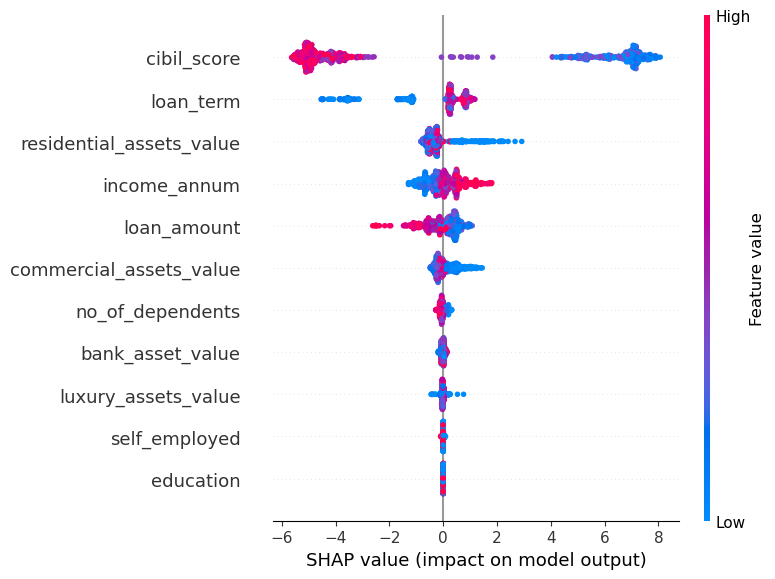

In [487]:
# THEN apply SHAP
import shap

# Train model
model.fit(X_train, y_train)

# Create explainer
explainer = shap.Explainer(model, X_train)

# Get SHAP values
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

In [488]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_pred = pipe.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[529   7]
 [ 12 306]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



In [489]:
import joblib

joblib.dump(best_model, "loan_approval_model.pkl")

['loan_approval_model.pkl']

In [490]:
model = joblib.load("loan_approval_model.pkl")